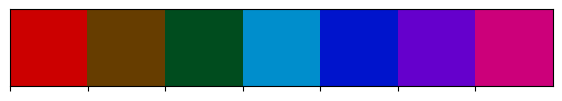

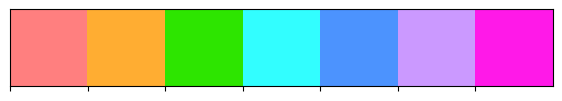

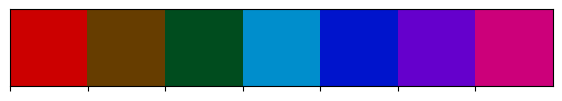

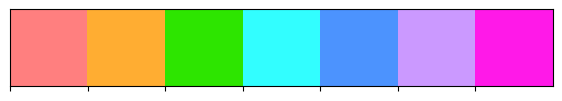

In [1]:
import os
import sys
import torch
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [2]:
grid_size = [10, 10]
n_seeds = 10
dryness = 0.05
gamma = 0.99
ep_window = 11
timesteps_freq = int(5e5)
n_rows, n_colums = grid_size

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/".format(n_rows, n_colums, dryness)
# main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/".format(n_rows, n_colums, dryness)

In [ ]:
def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j])
        confds.append(k)
    return np.array(confds)

def get_train_data(dir: str, n_seeds: int = 10, gamma: float = 0.99, ep_window: int =10, save_data: bool = False):
    max_x_axis = 0
    seeds_y_axis = []
    for seed in range(n_seeds):
        train_reward = np.load(dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
        ep_reward, ep_length = discount_episode_reward(train_reward, gamma=gamma)
        ep_timesteps_sum = sum_ep_timesteps(ep_length) 
        x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
        max_x_axis = np.max(x_axis) if np.max(x_axis) > max_x_axis else max_x_axis
        y_axis = []
        for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
            ind = np.where(ep_timesteps_sum > timestep)[0][0]
            value = np.mean(ep_reward[ind - ep_window: ind]) if ind > ep_window else ep_reward[ind]
            y_axis.append(value)
        seeds_y_axis.append(y_axis)
    lenghts = [len(l) for l in seeds_y_axis]
    cut_data = np.array([l[:min(lenghts)] for l in seeds_y_axis])
    conf_train = confidence_interval_2d(cut_data)
    if save_data:
        np.save(dir + "reward_train_all", seeds_y_axis)
        np.save(dir + "reward_train_mean", np.mean(cut_data, 0))
        np.save(dir + "reward_train_std", np.std(cut_data, 0))
        np.save(dir + "reward_train_confidence", conf_train)
    return seeds_y_axis, np.mean(cut_data, 0), np.std(cut_data, 0), conf_train

def load_train_reward(dir: str):
    reward_train_all = np.load(dir + "reward_train_all.npy")
    reward_train_mean = np.load(dir + "reward_train_mean.npy")
    reward_train_std = np.load(dir + "reward_train_std.npy")
    reward_train_confidence = np.load(dir + "reward_train_confidence.npy")
    return reward_train_all, reward_train_mean, reward_train_std, reward_train_confidence

In [ ]:
q_lrs = [0.0001]
r_lrs = [0.0001]
fig = plt.figure(figsize=(6, 4))
count = 0
for window_size in [11]:
    for q_lr in q_lrs:
        for r_lr in r_lrs:
            log_dir = main_dir + "window_{}/q_lr_{}/reward_lr_{}/".format(window_size, q_lr, r_lr)
            legend = "Window size = {}".format(window_size)
            # legend = "Q_lr = {}, R_lr = {}".format(q_lr, r_lr)
            seed_train, mean_train, _, _ = get_train_data(log_dir, n_seeds)
            for seed_tr in seed_train:
                plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
            plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=legend)
            count += 1

# log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
# seed_train, mean_train, _, _ = get_train_data(log_dir, n_seeds)
# for seed_tr in seed_train:
#     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
# plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label="Bird-eye-view")

# log_dir = main_dir + "q_learning/window_{}/q_lr_{}/reward_lr_{}/".format(window_size, q_lr, r_lr)
# seed_train, mean_train, _, _ = get_train_data(log_dir, n_seeds)
# for seed_tr in seed_train:
#     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, "--", lw=0.5,  c=dark_colors[count+1])
# plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, "--", lw=5,  c=dark_colors[count +1], alpha=0.7, label="Q-learning")

plt.xlabel(r"Training Timesteps ($10^{5}$)", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)
# plt.xticks(np.arange(0, len(seed_tr) + 2, 2) * timesteps_freq, np.arange(0, len(seed_tr) + 2, 2), fontsize=15)
plt.yticks(fontsize=12)
plt.grid(axis="y")
# plt.ylim(-13, 20)
plt.legend(fontsize=18)
plt.tight_layout()
# fig.savefig(main_dir + "/dry_{}_q_learning_training_curv_window_size_clip_no_legend.pdf".format(dryness), dpi=300)
# fig.savefig(main_dir + "q_learning/window_{}/q_learning_training_curv_hyperparameters.pdf".format(window_size), dpi=300)

In [35]:
np.load(log_dir +"joint_reward_11.npy"), np.load(log_dir +"monitor_reward_11.npy"), np.load(log_dir +"environment_reward_11.npy")

(array(-6.), array(-5.), array(-1.))

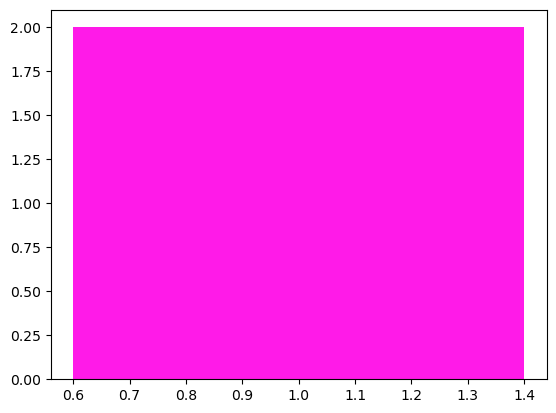

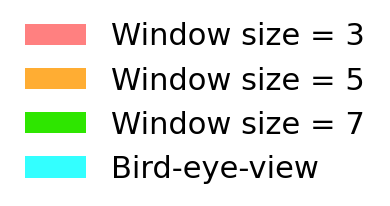

In [6]:
legends = ["Window size = 3", "Window size = 5", "Window size = 7", "Bird-eye-view"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", light_colors[i]) for i in range(7)]
fig = plt.figure(figsize=(4, 2))
fig.legend(handles, legends, fontsize=22, ncol=1, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig("../general_models/Plants/reward_model/{}_{}/".format(n_rows, n_colums) + "legend.pdf", dpi=300,)

In [42]:
len(seed_tr)

20

## plot std & mean

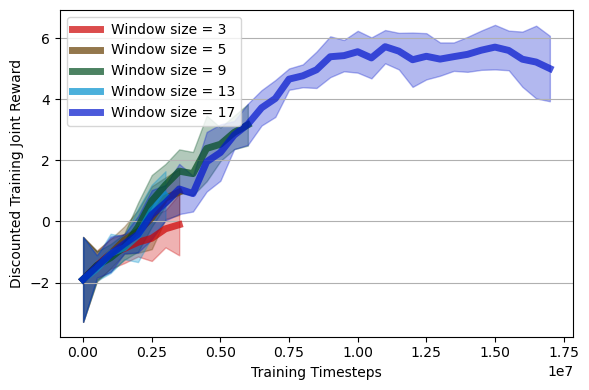

In [7]:
q_lrs = [0.0001]
r_lrs = [0.0001]
fig = plt.figure(figsize=(6, 4))
count = 0
for window_size in [3, 5, 9, 13, 17]:
    for q_lr in q_lrs:
        for r_lr in r_lrs:
            log_dir = main_dir + "window_{}/q_lr_{}/reward_lr_{}/".format(window_size, q_lr, r_lr)
            legend = "Window size = {}".format(window_size)
            _, mean_train, _, conf_train = get_train_data(log_dir, n_seeds)
            plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=legend)
            plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
            count += 1

# log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
# _, mean_train, _, conf_train = get_train_data(log_dir, n_seeds)
# plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label="Bird-view")
# plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)

plt.xlabel("Training Timesteps")
plt.ylabel("Discounted Training Joint Reward")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
fig.savefig(main_dir + "/dry_{}_std_training_curv_window_size.pdf".format(dryness), dpi=300)

## plot Training reward per room

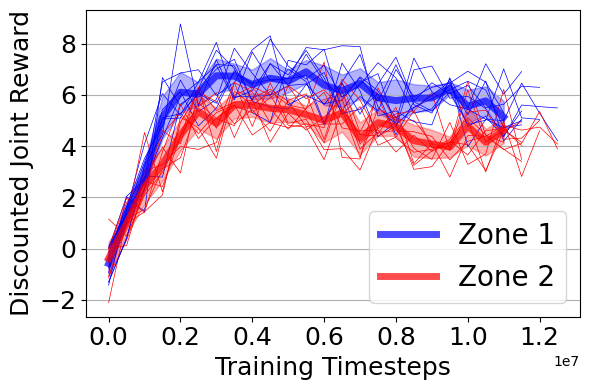

In [14]:
window_size = 11
ep_max_length = 100
discount = np.array([gamma**i for i in range(ep_max_length)])
# log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)
main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/".format(n_rows, n_colums, dryness)
log_dir = main_dir + "/room/window_{}/eps_decay_1e-05/q_lr_{}/reward_lr_{}/".format(window_size, 0.0001, 0.0001)

cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

fig = plt.figure(figsize=(6, 4))
one_seeds, two_seeds, three_seeds = [], [], []
for seed in range(n_seeds):
    agent_pos = np.load(log_dir + "/agent_locations_{}.npy".format(seed))
    train_reward = np.load(log_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    reward_1, reward_2, reward_3 = [], [], []
    
    for ep_train in range(len(agent_pos)):
        ones = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] < cut_indx))
        twos = np.squeeze(np.argwhere((agent_pos[ep_train, : , 1] > cut_indx) & (agent_pos[ep_train, : , 1] < cut_indx_1)))
        # three = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] > 6))
    
        reward_1.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        reward_2.append(np.sum(np.array(train_reward[ep_train])[twos] * discount[twos]))
        # reward_3.append(np.sum(np.array(train_reward[ep_train])[three] * discount[three]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    y_axis_1, y_axis_2, y_axis_3 = [], [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value_1 = np.mean(reward_1[ind - ep_window: ind]) if ind > ep_window else reward_1[ind]
        value_2 = np.mean(reward_2[ind - ep_window: ind]) if ind > ep_window else reward_2[ind]
        # value_3 = np.mean(reward_3[ind - ep_window: ind]) if ind > ep_window else reward_3[ind]

        y_axis_1.append(value_1)
        y_axis_2.append(value_2)
        # y_axis_3.append(value_3)
    plt.plot(x_axis, y_axis_1, lw=0.5, c="b")#, label="Zone 1" if seed==(n_seeds-1) else None)
    plt.plot(x_axis, y_axis_2, lw=0.5, c="r")#, label="Zone 2" if seed==(n_seeds-1) else None)
    # plt.plot(x_axis, y_axis_3, lw=0.5, c="black")#, label="Zone 3" if seed==(n_seeds-1) else None)

    one_seeds.append(y_axis_1)
    two_seeds.append(y_axis_2)
    # three_seeds.append(y_axis_3)
lenghts_1 = [len(l) for l in one_seeds]
lenghts_2 = [len(l) for l in two_seeds]
# lenghts_3 = [len(l) for l in three_seeds]

mean_1 = np.mean(np.array([l[:min(lenghts_1)] for l in one_seeds]), 0)
mean_2 = np.mean(np.array([l[:min(lenghts_2)] for l in two_seeds]), 0)
# mean_3 = np.mean(np.array([l[:min(lenghts_3)] for l in three_seeds]), 0)

std_1 = confidence_interval_2d(np.array([l[:min(lenghts_1)] for l in one_seeds]))
std_2 = confidence_interval_2d(np.array([l[:min(lenghts_2)] for l in two_seeds]))
# std_3 = confidence_interval_2d(np.array([l[:min(lenghts_3)] for l in three_seeds]))

plt.plot(np.arange(len(mean_1)) * timesteps_freq, mean_1, lw=5,  c="b", alpha=0.7, label="Zone 1")
plt.fill_between(np.arange(len(mean_1)) * timesteps_freq, mean_1 - std_1, mean_1 + std_1, color="b", alpha=0.3)

plt.plot(np.arange(len(mean_2)) * timesteps_freq, mean_2, lw=5,  c="r", alpha=0.7, label="Zone 2")
plt.fill_between(np.arange(len(mean_2)) * timesteps_freq, mean_2 - std_2, mean_2 + std_2, color="r", alpha=0.3)

# plt.plot(np.arange(len(mean_3)) * timesteps_freq, mean_3, lw=5,  c="black", alpha=0.7, label="Zone 3")
# plt.fill_between(np.arange(len(mean_3)) * timesteps_freq, mean_3 - std_2, mean_3 + std_3, color="black", alpha=0.3)

plt.xlabel("Training Timesteps", fontsize=18) #($10^{6}$)
plt.ylabel("Discounted Joint Reward", fontsize=18)
# plt.xticks(np.arange(60)[::10] * timesteps_freq, np.arange(0, 30, 5), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
# plt.ylim(-6, 9)
plt.grid(axis="y")
plt.legend(fontsize=20)
plt.tight_layout()
fig.savefig(log_dir + "room_reward_per_zone_training_curve.pdf", dpi=300)
# fig.savefig(log_dir + "/dry_{}_window_{}_rooms_training_clip.pdf".format(dryness, window_size), dpi=300)

# legend

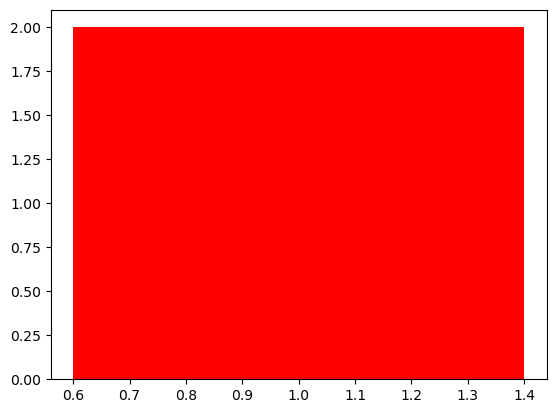

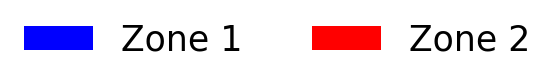

In [14]:
legends = ["Zone 1", "Zone 2"]
colors = ["b", "r"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", colors[i]) for i in range(2)]
fig = plt.figure(figsize=(5.5, 0.8))
fig.legend(handles, legends, fontsize=25, ncol=2, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig("../general_models/Plants/reward_model/10_10_channel/dry_0.05/room/window_11/" + "legend_horiz.pdf", dpi=300,)

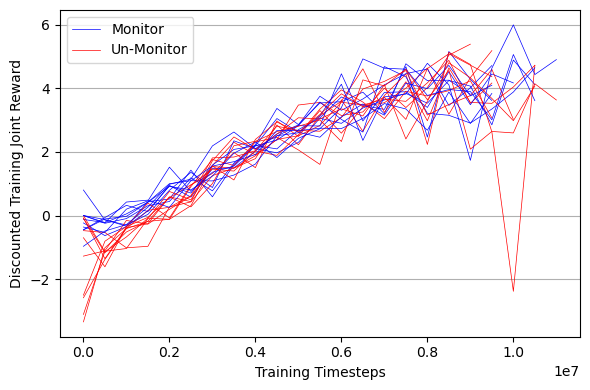

In [22]:
discount = np.array([gamma**i for i in range(ep_max_length)])
# log_dir = main_dir + "window_{}/q_lr_{}/reward_lr_{}/".format(window_size, 0.0001, 0.0001)
log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

fig = plt.figure(figsize=(6, 4))

monitor_seeds, unmonitor_seeds = [], []
for seed in range(n_seeds):
    monitor_states = np.load(log_dir + "/monitor_states_{}.npy".format(seed))
    train_reward = np.load(log_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    monitor_rewards, unmonitor_rewards = [], []
    for ep_train in range(len(train_reward)):
        ones = np.squeeze(np.argwhere(monitor_states[ep_train] == 1))
        zeros = np.squeeze(np.argwhere(monitor_states[ep_train] == 0))
    
        monitor_rewards.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        unmonitor_rewards.append(np.sum(np.array(train_reward[ep_train])[zeros] * discount[zeros]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    monitor_y_axis, unmonitor_y_axis = [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        mon_value = np.mean(monitor_rewards[ind - ep_window: ind]) if ind > ep_window else monitor_rewards[ind]
        unmon_value = np.mean(unmonitor_rewards[ind - ep_window: ind]) if ind > ep_window else unmonitor_rewards[ind]
        monitor_y_axis.append(mon_value)
        unmonitor_y_axis.append(unmon_value)
    plt.plot(x_axis, monitor_y_axis, lw=0.5, c="b", label="Monitor" if seed==(n_seeds-1) else None)
    plt.plot(x_axis, unmonitor_y_axis, lw=0.5, c="r", label="Un-Monitor" if seed==(n_seeds-1) else None)
    monitor_seeds.append(monitor_y_axis)
    unmonitor_seeds.append(unmonitor_y_axis)

mon_lenghts = [len(l) for l in monitor_seeds]
unmon_lenghts = [len(l) for l in unmonitor_seeds]

mon_mean = np.mean(np.array([l[:min(mon_lenghts)] for l in monitor_seeds]), 0)
unmon_mean = np.mean(np.array([l[:min(unmon_lenghts)] for l in unmonitor_seeds]), 0)
mon_std = np.std(np.array([l[:min(mon_lenghts)] for l in monitor_seeds]), 0)
unmonstd = np.std(np.array([l[:min(unmon_lenghts)] for l in unmonitor_seeds]), 0)

plt.xlabel("Training Timesteps")
plt.ylabel("Discounted Training Joint Reward")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
# fig.savefig(log_dir + "/dry_{}_monitor_training.pdf".format(dryness), dpi=300)

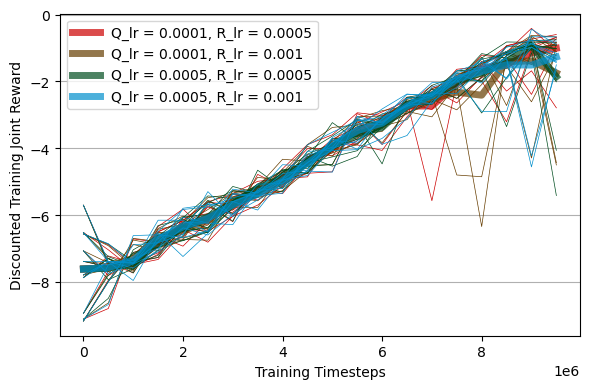

In [19]:
q_lrs = [0.0001, 0.0005]
r_lrs = [0.0005, 0.001]
fig = plt.figure(figsize=(6, 4))
count = 0
for q_lr in q_lrs:
    for r_lr in r_lrs:
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
        legend = "Q_lr = {}, R_lr = {}".format(q_lr, r_lr)
        seed_train, mean_train, _, _ = get_train_data(log_dir)
        for seed_tr in seed_train:
            plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=legend)
        count += 1

plt.xlabel("Training Timesteps")
plt.ylabel("Discounted Training Joint Reward")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
# fig.savefig(main_dir + "/full_obs_training_curv_hyperparameters.pdf".format(window_size), dpi=300)